Mounted at /content/drive


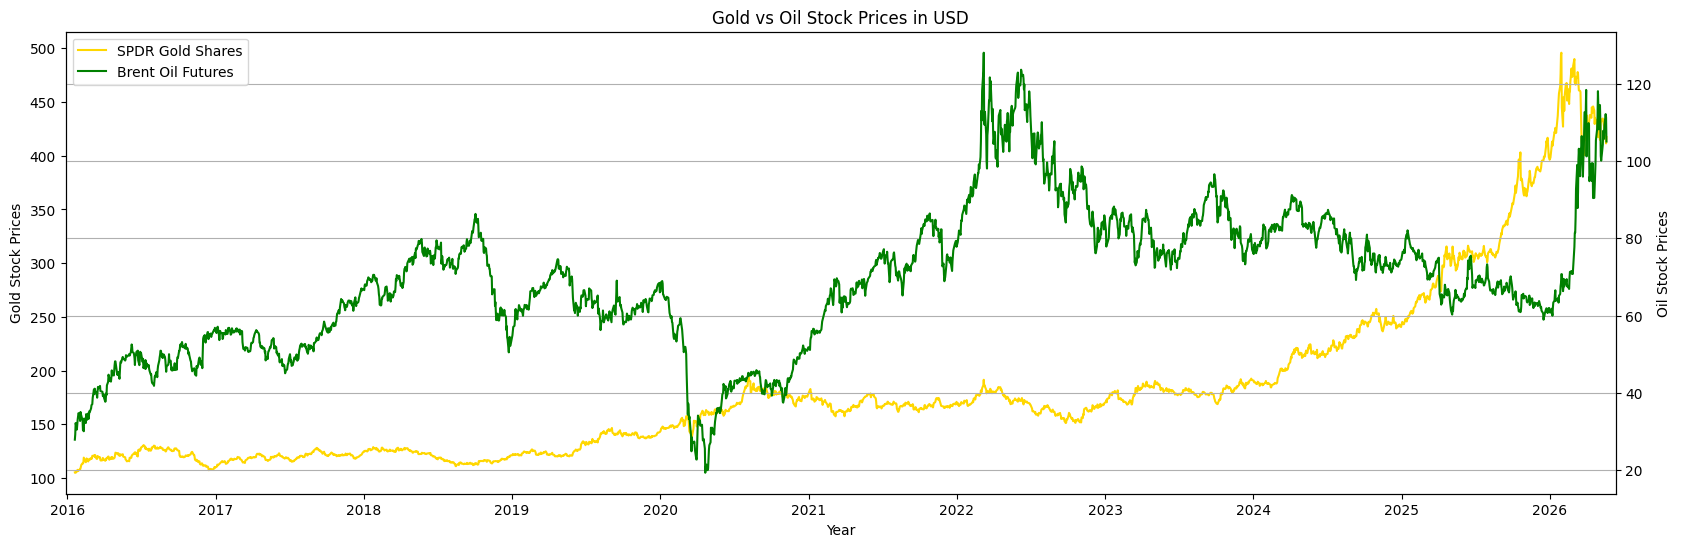

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

#oil data: https://www.investing.com/commodities/brent-oil
#gold data: https://www.investing.com/etfs/spdr-gold-trust

od= pd.read_csv('/content/drive/MyDrive/VSTE_gold_and_oil/oil_data.csv')
gd = pd.read_csv('/content/drive/MyDrive/VSTE_gold_and_oil/gold_data.csv')

#merge the two datasets to only include the price and date
merged_info = pd.merge(od[['Date','Price']],
                       gd[['Date','Price']],
                       on='Date')

merged_info.to_csv('/content/drive/MyDrive/VSTE_gold_and_oil/merged_info.csv', index=False)

merged_info['Date'] = pd.to_datetime(merged_info['Date'])

fig, ax1 = plt.subplots(figsize=(20,6)) # Create one subplot for the first y-axis
ax2 = ax1.twinx() # Create a second y-axis that shares the same x-axis

#format the years for the y axis
ax1.xaxis.set_major_locator(mdates.YearLocator(1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax1.plot(merged_info['Date'],
         merged_info['Price_y'],
         label='SPDR Gold Shares',
         color='gold')

ax1.set_xlabel('Year')
ax1.set_ylabel('Gold Stock Prices')

ax2.plot(merged_info['Date'],
         merged_info['Price_x'],
         label='Brent Oil Futures',
         color='green')

ax2.set_ylabel('Oil Stock Prices')
plt.title('Gold vs Oil Stock Prices in USD')

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax2.legend(lines + lines2, labels + labels2, loc='upper left')

#have the data close to each x-axis
ax1.margins(x=0.006)
ax2.margins(x=0.006)

plt.grid(True)
plt.show()

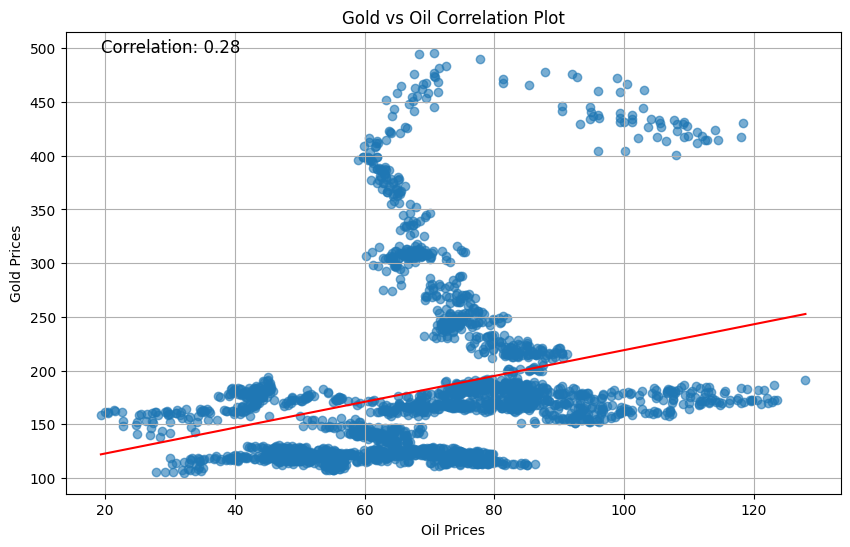

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# x and y values
x = merged_info['Price_x']  # Oil
y = merged_info['Price_y']  # Gold

# Create figure
plt.figure(figsize=(10,6))

# Scatter plot
plt.scatter(x, y, alpha=0.6)

# Best fit line
plt.plot(np.unique(x),
         np.poly1d(np.polyfit(x, y, 1))
         (np.unique(x)),
         color='red')

# Correlation coefficient
correlation = x.corr(y)

# Titles and labels
plt.title('Gold vs Oil Correlation Plot')
plt.xlabel('Oil Prices')
plt.ylabel('Gold Prices')

# Display correlation on graph
plt.text(min(x),
         max(y),
         f'Correlation: {correlation:.2f}',
         fontsize=12)

plt.grid(True)
plt.show()

Downloading data from yahoo finance

[*********************100%***********************]  3 of 3 completed
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Data collected successfully!
                 Gold    WTI_Oil   Brent_Oil  Gold_Return  WTI_Oil_Return  \
Date                                                                        
2007-07-31  77.050003  78.209999  666.900024     1.714821        1.780229   
2007-08-01  75.349998  76.529999  663.599976    -2.231070       -2.171470   
2007-08-02  75.760002  76.860001  664.599976     0.542657        0.430279   
2007-08-03  74.750000  75.480003  672.500000    -1.342126       -1.811783   
2007-08-06  71.169998  72.059998  671.500000    -4.907786       -4.636869   

            Brent_Oil_Return  
Date                          
2007-07-31          0.420744  
2007-08-01         -0.496062  
2007-08-02          0.150580  
2007-08-03          1.181679  
2007-08-06         -0.148810  
                 Gold    WTI_Oil    Brent_Oil  Gold_Return  WTI_Oil_Return  \
Date                                                                         
2026-06-01  94.980003  92.160004  4475.200195     3.133444

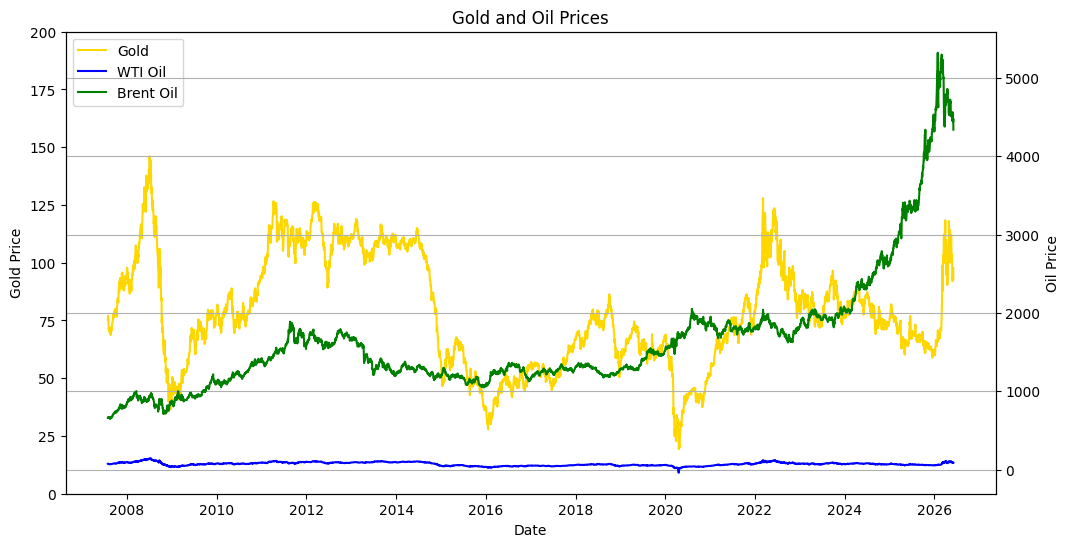

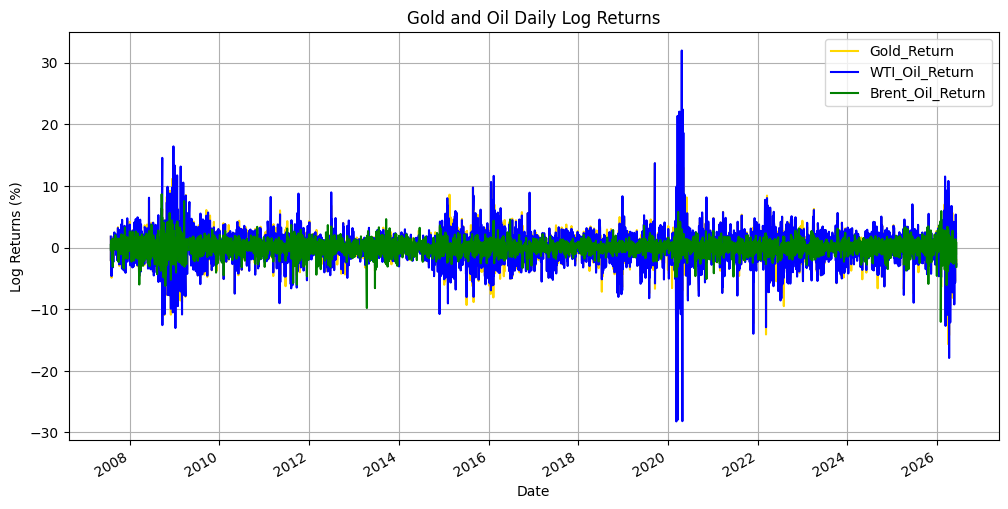

In [ ]:
# Install first if needed:
# pip install yfinance pandas matplotlib openpyxl

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

# -----------------------------
# 1. Define tickers
# -----------------------------
tickers = {
    "Gold": "GC=F",        # Gold Futures
    "WTI_Oil": "CL=F",    # Crude Oil WTI Futures
    "Brent_Oil": "BZ=F"   # Brent Crude Oil Futures
}

# -----------------------------
# 2. Download data from Yahoo Finance
# -----------------------------
start_date = "2000-01-01"
end_date = datetime.today().strftime("%Y-%m-%d")

data = yf.download(
    list(tickers.values()),
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False
)

# -----------------------------
# 3. Keep Adjusted Close prices
# -----------------------------
prices = data["Adj Close"].copy()

# Rename columns
prices.columns = tickers.keys()

# -----------------------------
# 4. Clean missing values
# -----------------------------
prices = prices.dropna()

# -----------------------------
# 5. Calculate log returns
# -----------------------------
returns = pd.DataFrame()

for col in prices.columns:
    returns[col + "_Return"] = 100 * (prices[col] / prices[col].shift(1)).apply(lambda x: pd.NA if x <= 0 else x)

returns = 100 * (prices / prices.shift(1)).apply(lambda x: np.log(x))
returns.columns = [col + "_Return" for col in prices.columns]
returns = returns.dropna()

# -----------------------------
# 6. Combine prices and returns
# -----------------------------
final_data = pd.concat([prices, returns], axis=1).dropna()

# -----------------------------
# 7. Save files
# -----------------------------
final_data.to_csv("gold_oil_yahoo_data.csv")
final_data.to_excel("gold_oil_yahoo_data.xlsx")

print("Data collected successfully!")
print(final_data.head())
print(final_data.tail())

# -----------------------------
# 8. Plot prices
# -----------------------------
fig, ax1 = plt.subplots(figsize=(12,6))

# Left axis
ax1.plot(
    prices.index,
    prices['Gold'],
    color='gold',
    label='Gold'
)

ax1.set_xlabel('Date')

ax1.set_ylim(0, 200)

ax1.set_ylabel('Gold Price', color='k')
ax1.tick_params(axis='y', labelcolor='k')

# Right axis
ax2 = ax1.twinx()

ax2.plot(
    prices.index,
    prices['WTI_Oil'],
    color='blue',
    label='WTI Oil'
)

ax2.plot(
    prices.index,
    prices['Brent_Oil'],
    color='green',
    label='Brent Oil'
)

ax2.set_ylabel('Oil Price', color='k')
ax2.tick_params(axis='y')

# Title
plt.title('Gold and Oil Prices')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper left'
)

plt.grid(True)
plt.show()

# -----------------------------
# 9. Plot returns
# -----------------------------
returns.plot(
    figsize=(12, 6),
    color=[
        'gold',   # Gold_Return
        'blue',   # WTI_Oil_Return
        'green'   # Brent_Oil_Return
    ]
)

plt.title("Gold and Oil Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Returns (%)")
plt.grid(True)

plt.show()

                 Gold    WTI_Oil   Brent_Oil  Gold_Return  WTI_Oil_Return  \
Date                                                                        
2007-07-31  77.050003  78.209999  666.900024     1.714821        1.780229   
2007-08-01  75.349998  76.529999  663.599976    -2.231070       -2.171470   
2007-08-02  75.760002  76.860001  664.599976     0.542657        0.430279   
2007-08-03  74.750000  75.480003  672.500000    -1.342126       -1.811783   
2007-08-06  71.169998  72.059998  671.500000    -4.907786       -4.636869   

            Brent_Oil_Return  
Date                          
2007-07-31          0.420744  
2007-08-01         -0.496062  
2007-08-02          0.150580  
2007-08-03          1.181679  
2007-08-06         -0.148810  
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4687 entries, 2007-07-31 to 2026-06-05
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gold              46

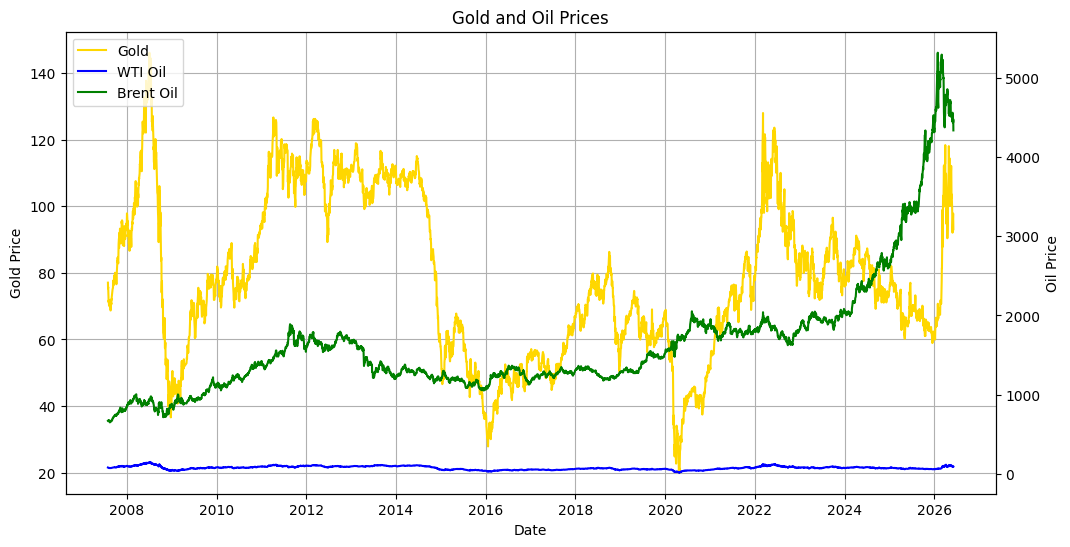

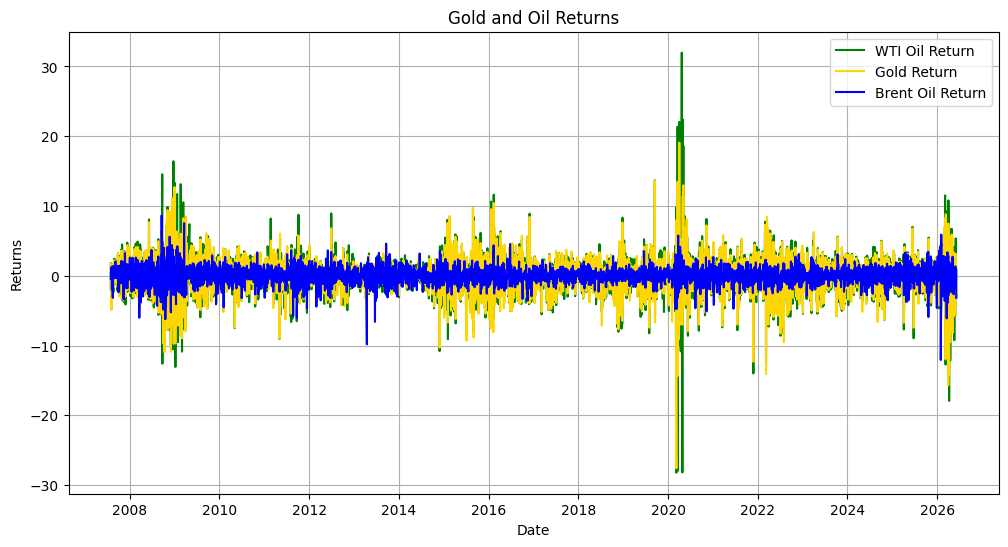

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("gold_oil_yahoo_data.csv", index_col=0, parse_dates=True)

print(df.head())
print(df.info())

# -----------------------------
# Plot Prices with right axis
# -----------------------------
fig, ax1 = plt.subplots(figsize=(12,6))

# LEFT axis → Gold
ax1.plot(
    df.index,
    df["Gold"],
    color="gold",
    label="Gold"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Gold Price", color="k")
ax1.tick_params(axis="y", labelcolor="k")

# RIGHT axis → Oils
ax2 = ax1.twinx()

ax2.plot(
    df.index,
    df["WTI_Oil"],
    color="blue",
    label="WTI Oil"
)

ax2.plot(
    df.index,
    df["Brent_Oil"],
    color="green",
    label="Brent Oil"
)

ax2.set_ylabel("Oil Price", color="k")
ax2.tick_params(axis="y")

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.title("Gold and Oil Prices")
ax1.grid(True)

plt.show()

# -----------------------------
# Plot Returns
# -----------------------------
plt.figure(figsize=(12,6))

plt.plot(df.index, df["WTI_Oil_Return"], label="WTI Oil Return", color="green")
plt.plot(df.index, df["Gold_Return"], label="Gold Return", color="gold")
plt.plot(df.index, df["Brent_Oil_Return"], label="Brent Oil Return", color="blue")

plt.title("Gold and Oil Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.legend()
plt.grid(True)

plt.show()

Descriptive Statistics

In [ ]:
from scipy.stats import jarque_bera

# Descriptive statistics
desc = df[[
    "Gold_Return",
    "WTI_Oil_Return",
    "Brent_Oil_Return"
]].describe().T

# Add skewness and kurtosis
desc["Skewness"] = df[[
    "Gold_Return",
    "WTI_Oil_Return",
    "Brent_Oil_Return"
]].skew()

desc["Kurtosis"] = df[[
    "Gold_Return",
    "WTI_Oil_Return",
    "Brent_Oil_Return"
]].kurtosis()

# Jarque-Bera
jb_results = []

for col in ["Gold_Return", "WTI_Oil_Return", "Brent_Oil_Return"]:
    jb_stat, jb_p = jarque_bera(df[col].dropna())
    jb_results.append([jb_stat, jb_p])

desc["JB Statistic"] = [x[0] for x in jb_results]
desc["JB p-value"] = [x[1] for x in jb_results]

print(desc)

# Save table
desc.to_csv("descriptive_statistics.csv")

                   count      mean       std        min       25%       50%  \
Gold_Return       4687.0  0.012367  2.381132 -27.575146 -1.041418  0.074000   
WTI_Oil_Return    4687.0  0.016340  2.739831 -28.220613 -1.247424  0.088643   
Brent_Oil_Return  4687.0  0.040176  1.156796 -12.065692 -0.490233  0.048199   

                       75%        max  Skewness   Kurtosis  JB Statistic  \
Gold_Return       1.166007  19.077404 -0.495880   8.987904  15929.977315   
WTI_Oil_Return    1.314711  31.963363  0.004639  17.464461  59429.720910   
Brent_Oil_Return  0.631730   8.643166 -0.535309   7.481590  11127.957104   

                  JB p-value  
Gold_Return              0.0  
WTI_Oil_Return           0.0  
Brent_Oil_Return         0.0  


In [ ]:
pd.read_csv("descriptive_statistics.csv")

,Unnamed: 0,count,mean,std,min,25%,50%,75%,max,Skewness,Kurtosis,JB Statistic,JB p-value
0,Gold_Return,4687.0,0.012367,2.381132,-27.575146,-1.041418,0.074000,1.166007,19.077404,-0.495880,8.987904,15929.977315,0.0
1,WTI_Oil_Return,4687.0,0.016340,2.739831,-28.220613,-1.247424,0.088643,1.314711,31.963363,0.004639,17.464461,59429.720910,0.0
2,Brent_Oil_Return,4687.0,0.040176,1.156796,-12.065692,-0.490233,0.048199,0.631730,8.643166,-0.535309,7.481590,11127.957104,0.0


Stationarity Test (ADF)

In [ ]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, name):

    result = adfuller(series.dropna())

    print(f"\nADF Test: {name}")
    print(f"ADF Statistic : {result[0]}")
    print(f"p-value       : {result[1]}")

    if result[1] < 0.05:
        print("Stationary")
    else:
        print("Non-Stationary")

# Test returns
adf_test(df["Gold_Return"], "Gold Return")
adf_test(df["WTI_Oil_Return"], "WTI Oil Return")
adf_test(df["Brent_Oil_Return"], "Brent Oil Return")


ADF Test: Gold Return
ADF Statistic : -15.008639471436949
p-value       : 1.0635417400466908e-27
Stationary

ADF Test: WTI Oil Return
ADF Statistic : -12.053096203456066
p-value       : 2.5702220173700915e-22
Stationary

ADF Test: Brent Oil Return
ADF Statistic : -69.28711394796261
p-value       : 0.0
Stationary


Correlation Matrix

                  Gold_Return  WTI_Oil_Return  Brent_Oil_Return
Gold_Return          1.000000        0.882331          0.156422
WTI_Oil_Return       0.882331        1.000000          0.162655
Brent_Oil_Return     0.156422        0.162655          1.000000


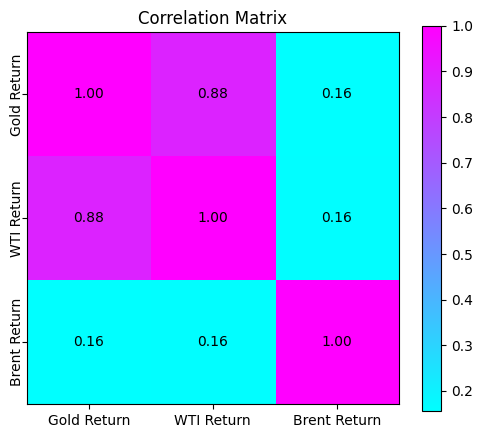

In [ ]:
corr = df[[
    "Gold_Return",
    "WTI_Oil_Return",
    "Brent_Oil_Return"
]].corr()

print(corr)

# Heatmap
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.imshow(corr, cmap="cool", interpolation="none")

plt.colorbar()

labels = [
    "Gold Return",
    "WTI Return",
    "Brent Return"
]

plt.xticks(range(len(labels)), labels, rotation=0)
plt.yticks(range(len(labels)), labels, rotation=90, ha="center", va="center")

for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")

plt.show()

VAR Model (Core Analysis)

In [ ]:
pip install statsmodels

In [ ]:
from statsmodels.tsa.api import VAR

# Select variables
var_data = df[[
    "Gold_Return",
    "WTI_Oil_Return"
]].dropna()

# -----------------------------
# Lag selection
# -----------------------------
model = VAR(var_data)
lag_selection = model.select_order(maxlags=10)

print(lag_selection.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        2.247       2.249       9.456       2.248
1        2.242       2.250       9.408       2.244
2        2.231       2.245       9.312       2.236
3        2.219      2.238*       9.194      2.225*
4        2.219       2.244       9.200       2.228
5        2.219       2.249       9.198       2.230
6        2.216       2.252       9.175       2.229
7        2.216       2.257       9.166       2.230
8        2.214       2.260       9.149       2.230
9        2.212       2.264       9.132       2.230
10      2.209*       2.267      9.103*       2.229
--------------------------------------------------


In [ ]:
from statsmodels.tsa.api import VAR

# Select variables
var_data = df[[
    "Gold_Return",
    "WTI_Oil_Return"
]].dropna()

# -----------------------------
# Lag selection
# -----------------------------
model = VAR(var_data)

lag_selection = model.select_order(maxlags=10)

print(lag_selection.summary())

# -----------------------------
# Fit VAR model
# -----------------------------
var_model = model.fit(3)

print(var_model.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        2.247       2.249       9.456       2.248
1        2.242       2.250       9.408       2.244
2        2.231       2.245       9.312       2.236
3        2.219      2.238*       9.194      2.225*
4        2.219       2.244       9.200       2.228
5        2.219       2.249       9.198       2.230
6        2.216       2.252       9.175       2.229
7        2.216       2.257       9.166       2.230
8        2.214       2.260       9.149       2.230
9        2.212       2.264       9.132       2.230
10      2.209*       2.267      9.103*       2.229
--------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 08, Jun, 2026
Time:                     12:19:40
------------------------------------------------------------

Granger Causality Test

In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

# Variables
gc_data = df[[
    "Gold_Return",
    "WTI_Oil_Return"
]].dropna()

# -----------------------------
# Does Oil cause Gold?
# -----------------------------
print("\nWTI Oil → Gold")

grangercausalitytests(
    gc_data[["Gold_Return", "WTI_Oil_Return"]],
    maxlag=5,
    verbose=True
)

# -----------------------------
# Does Gold cause Oil?
# -----------------------------
print("\nGold → WTI Oil")

grangercausalitytests(
    gc_data[["WTI_Oil_Return", "Gold_Return"]],
    maxlag=5,
    verbose=True
)


WTI Oil → Gold

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=12.8827 , p=0.0003  , df_denom=4683, df_num=1
ssr based chi2 test:   chi2=12.8910 , p=0.0003  , df=1
likelihood ratio test: chi2=12.8733 , p=0.0003  , df=1
parameter F test:         F=12.8827 , p=0.0003  , df_denom=4683, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=7.8819  , p=0.0004  , df_denom=4680, df_num=2
ssr based chi2 test:   chi2=15.7806 , p=0.0004  , df=2
likelihood ratio test: chi2=15.7541 , p=0.0004  , df=2
parameter F test:         F=7.8819  , p=0.0004  , df_denom=4680, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=5.3072  , p=0.0012  , df_denom=4677, df_num=3
ssr based chi2 test:   chi2=15.9453 , p=0.0012  , df=3
likelihood ratio test: chi2=15.9182 , p=0.0012  , df=3
parameter F test:         F=5.3072  , p=0.0012  , df_denom=4677, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


ssr based F test:         F=7.2507  , p=0.0000  , df_denom=4674, df_num=4
ssr based chi2 test:   chi2=29.0588 , p=0.0000  , df=4
likelihood ratio test: chi2=28.9690 , p=0.0000  , df=4
parameter F test:         F=7.2507  , p=0.0000  , df_denom=4674, df_num=4

Granger Causality
number of lags (no zero) 5
ssr based F test:         F=7.0982  , p=0.0000  , df_denom=4671, df_num=5
ssr based chi2 test:   chi2=35.5748 , p=0.0000  , df=5
likelihood ratio test: chi2=35.4403 , p=0.0000  , df=5
parameter F test:         F=7.0982  , p=0.0000  , df_denom=4671, df_num=5


{np.int64(1): ({'ssr_ftest': (np.float64(4.617715004842892),
    np.float64(0.03169447258752093),
    np.float64(4683.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(4.620673182296347),
    np.float64(0.03158883844152043),
    np.int64(1)),
   'lrtest': (np.float64(4.6183965502314095),
    np.float64(0.03163079352365986),
    np.int64(1)),
   'params_ftest': (np.float64(4.61771500484366),
    np.float64(0.03169447258749861),
    np.float64(4683.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(11.412219119033153),
    np.float64(1.1370588657940937e-05),
    np.float64(4680.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(22.848823321653985),
    np.float64(1.0925493342138864e-05),
    np.int64(2)),
   'lrtest': (np.float64(22.793286770262057),
    np.float64(1.1233126913103386e-05),
    np.int64(2)),
   'params_ftest': (np.float64(11.412219119034178),
    np.float64(1.137058865793201e-05),
    np.float64(4680.0),
    2.0)},
   array([[0., 0., 

Impulse Response Function (IRF)

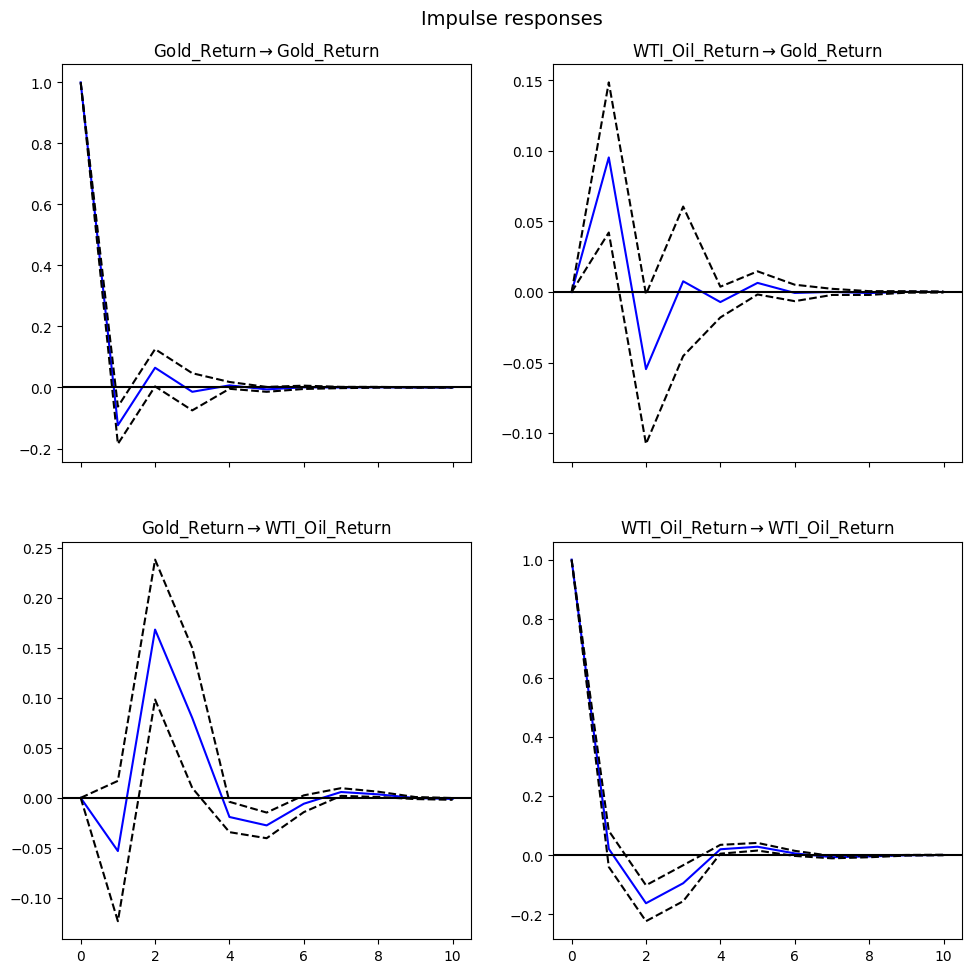

In [ ]:
# -----------------------------
# IRF Analysis
# -----------------------------
irf = var_model.irf(10)

# Plot responses
irf.plot(orth=False)

plt.show()

Forecast Error Variance Decomposition (FEVD)

FEVD for Gold_Return
     Gold_Return  WTI_Oil_Return
0       1.000000        0.000000
1       0.997405        0.002595
2       0.996559        0.003441
3       0.996542        0.003458
4       0.996528        0.003472
5       0.996516        0.003484
6       0.996516        0.003484
7       0.996516        0.003484
8       0.996516        0.003484
9       0.996516        0.003484

FEVD for WTI_Oil_Return
     Gold_Return  WTI_Oil_Return
0       0.782829        0.217171
1       0.782906        0.217094
2       0.778477        0.221523
3       0.777027        0.222973
4       0.776957        0.223043
5       0.776817        0.223183
6       0.776809        0.223191
7       0.776803        0.223197
8       0.776801        0.223199
9       0.776801        0.223199


None


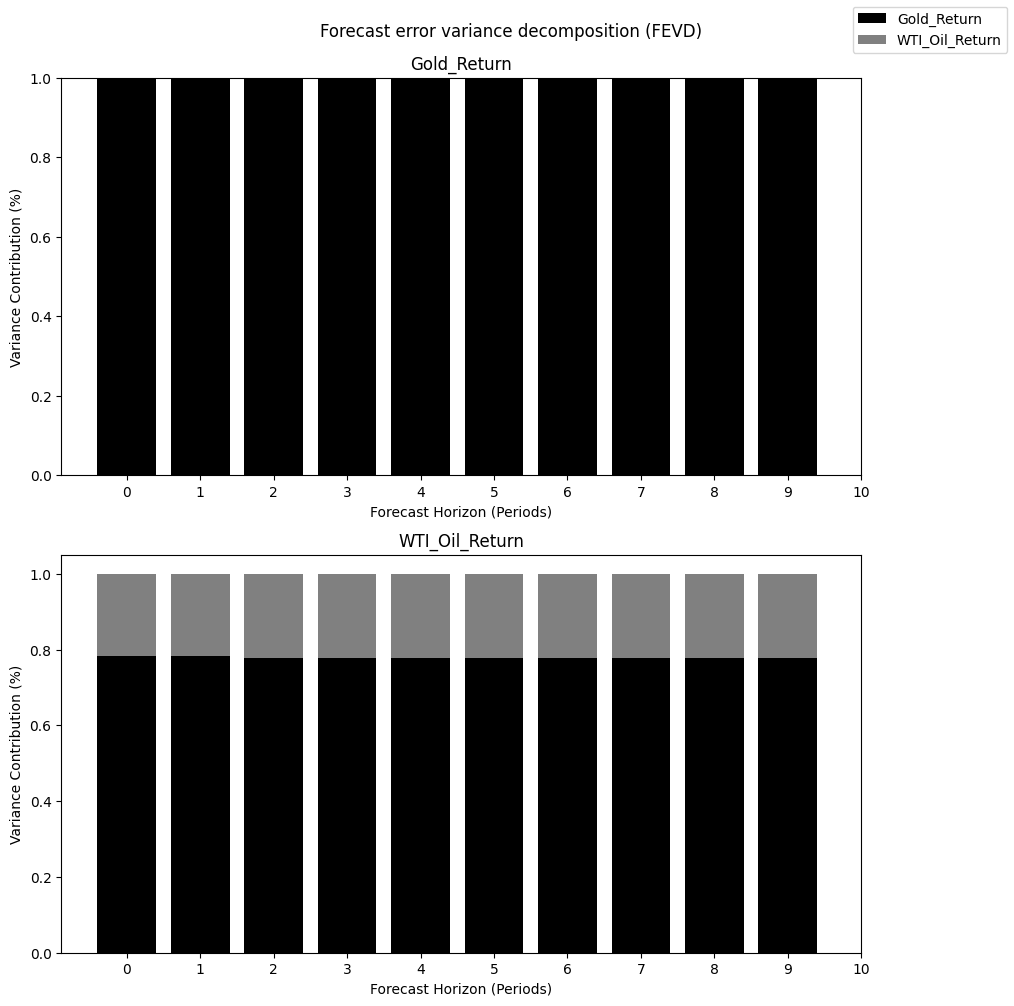

In [ ]:
# # -----------------------------
# # FEVD
# # -----------------------------
# fevd = var_model.fevd(10)

# print(fevd.summary())

# # Plot
# fevd.plot()

# plt.show()

# -----------------------------
# FEVD
# -----------------------------
fevd = var_model.fevd(10)

print(fevd.summary())

# Create figure
fig = fevd.plot()

# Edit all subplot axes
for ax in fig.axes:
    ax.set_xlabel("Forecast Horizon (Periods)")
    ax.set_ylabel("Variance Contribution (%)")

    # Show x-axis numbers on every chart
    ax.set_xticks(range(0, 11))
    ax.tick_params(axis="x", labelbottom=True)

plt.savefig(
    "FEVD.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Stability Test

In [ ]:
# -----------------------------
# Stability Condition
# -----------------------------
stability = var_model.is_stable()

print("Is the VAR model stable?")
print(stability)

Is the VAR model stable?
True


Residual Diagnostics

Serial Correlation Test

In [ ]:
from statsmodels.stats.stattools import durbin_watson

out = durbin_watson(var_model.resid)

for col, val in zip(var_data.columns, out):
    print(col, ":", round(val, 2))

Gold_Return : 2.0
WTI_Oil_Return : 2.0


Robustness Check with Brent Oil

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        2.004      2.006*       7.417      2.005*
1       2.004*       2.012      7.416*       2.007
2        2.004       2.018       7.419       2.009
3        2.006       2.025       7.430       2.012
4        2.006       2.031       7.435       2.015
5        2.007       2.037       7.440       2.017
6        2.007       2.043       7.442       2.020
7        2.007       2.048       7.437       2.021
8        2.007       2.054       7.438       2.023
9        2.007       2.059       7.438       2.025
10       2.007       2.065       7.444       2.028
--------------------------------------------------
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 08, Jun, 2026
Time:                     12:19:48
------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


parameter F test:         F=1.3748  , p=0.2485  , df_denom=4677, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.1883  , p=0.3137  , df_denom=4674, df_num=4
ssr based chi2 test:   chi2=4.7625  , p=0.3125  , df=4
likelihood ratio test: chi2=4.7601  , p=0.3128  , df=4
parameter F test:         F=1.1883  , p=0.3137  , df_denom=4674, df_num=4

Granger Causality
number of lags (no zero) 5
ssr based F test:         F=0.9511  , p=0.4466  , df_denom=4671, df_num=5
ssr based chi2 test:   chi2=4.7667  , p=0.4450  , df=5
likelihood ratio test: chi2=4.7643  , p=0.4453  , df=5
parameter F test:         F=0.9511  , p=0.4466  , df_denom=4671, df_num=5


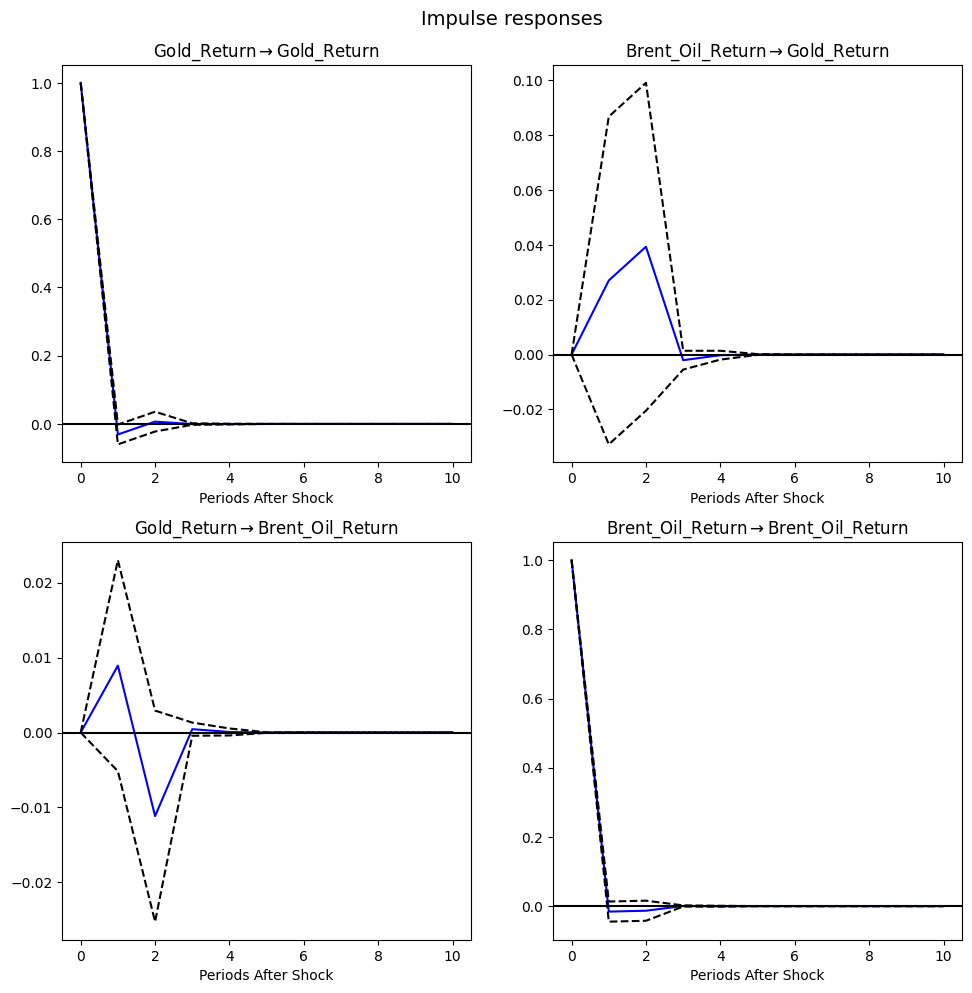

FEVD for Gold_Return
     Gold_Return  Brent_Oil_Return
0       1.000000          0.000000
1       0.999833          0.000167
2       0.999478          0.000522
3       0.999477          0.000523
4       0.999477          0.000523
5       0.999477          0.000523
6       0.999477          0.000523
7       0.999477          0.000523
8       0.999477          0.000523
9       0.999477          0.000523

FEVD for Brent_Oil_Return
     Gold_Return  Brent_Oil_Return
0       0.024861          0.975139
1       0.025101          0.974899
2       0.025708          0.974292
3       0.025709          0.974291
4       0.025709          0.974291
5       0.025709          0.974291
6       0.025709          0.974291
7       0.025709          0.974291
8       0.025709          0.974291
9       0.025709          0.974291


None


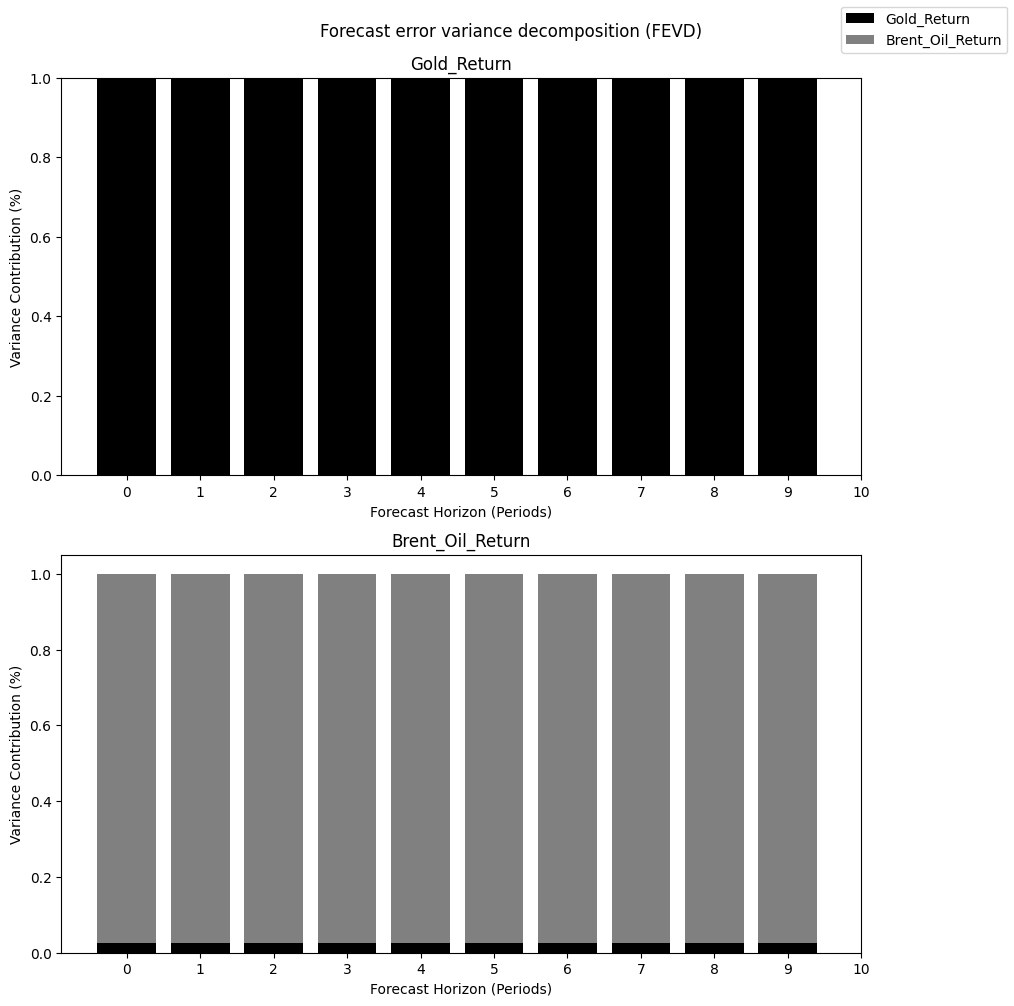

In [ ]:
# =====================================================
# STEP 13: Robustness Check with Brent Oil
# =====================================================

from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests
import matplotlib.pyplot as plt

brent_data = df[[
    "Gold_Return",
    "Brent_Oil_Return"
]].dropna()

brent_model = VAR(brent_data)

brent_lag = brent_model.select_order(maxlags=10)
print(brent_lag.summary())

brent_var = brent_model.fit(2)
print(brent_var.summary())

print("\nBrent Oil → Gold")
grangercausalitytests(
    brent_data[["Gold_Return", "Brent_Oil_Return"]],
    maxlag=5,
    verbose=True
)

print("\nGold → Brent Oil")
grangercausalitytests(
    brent_data[["Brent_Oil_Return", "Gold_Return"]],
    maxlag=5,
    verbose=True
)


brent_irf = brent_var.irf(10)
fig = brent_irf.plot(orth=False)
# Add labels to every subplot
for ax in fig.axes:
    # Add axis labels
    ax.set_xlabel("Periods After Shock")

    # Force x-axis numbers to show
    ax.tick_params(
        axis="x",
        labelbottom=True
    )

plt.savefig(
    "IRF_Gold_Brent.png",
    dpi=300,
)

plt.show()

# brent_irf = brent_var.irf(10)
# brent_irf.plot(orth=False)
# plt.savefig("IRF_Gold_Brent.png", dpi=300, bbox_inches="tight")
# plt.show()


# brent_fevd = brent_var.fevd(10)
# print(brent_fevd.summary())

# brent_fevd.plot()
# plt.savefig("FEVD_Gold_Brent.png", dpi=300, bbox_inches="tight")

# plt.show()


brent_fevd = brent_var.fevd(10)
print(brent_fevd.summary())

fig = brent_fevd.plot()

# Add labels to all FEVD subplots
for ax in fig.axes:
    ax.set_xlabel("Forecast Horizon (Periods)")
    ax.set_ylabel("Variance Contribution (%)")

    # Force x-axis numbers to appear
    ax.set_xticks(range(0, 11))
    ax.tick_params(axis="x", labelbottom=True)

plt.savefig(
    "FEVD_Gold_Brent.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

